<a href="https://colab.research.google.com/github/Rufidatul726/6thSemester/blob/temp/TBDiagnosis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Importing the necessary modules
import pandas as pd
import numpy as np
from skimage.io import imread
from skimage.transform import resize
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import re
import glob
import numpy as np
from skimage.io import imread
from skimage.transform import resize
from google.colab import drive

In [2]:
drive.mount('/content/drive')

# Getting the list of files in the folder
image_paths = glob.glob('/content/drive/MyDrive/CXR_png/*.png')

# Converting the images into numpy arrays
data = []
images = []

for path in image_paths:
    image = imread(path, as_gray=True) # Reading the image as grayscale
    image = resize(image, (224, 224)) # Resizing the image to 224x224 pixels
    images.append(image)
images = np.array(images)

# Normalizing the images by dividing them by 255
images = images / 255
images_2d = images.reshape(-1, 224*224)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
text_paths = glob.glob('/content/drive/MyDrive/ClinicalReadings/*.txt')

labels = [] # You need to fill this with your own labels
genders = []
ages = []

for i, path in enumerate(text_paths):
    # Reading the text file
    with open(path, 'r') as f:
        text = f.read()

    # Splitting the text into lines
    lines = text.split('\n')

    # Extracting the gender and age from the first line
    lines[0] = re.sub(r"(\D)(\d)", r"\1 \2", lines[0])
    lines[1] = re.sub(r"(\D)(\d)", r"\1 \2", lines[1])
    lines[0] = lines[0].replace(",", "")
    lines[0] = lines[0].replace("yrs", "")
    gender, age = lines[0].split()

    # Extracting the PTB status and type from the second line
    lines[1]=lines[1].replace("\t", "")
    if lines[1] == "" or lines[1].isspace():
      ptb_status= lines[2]
    else:
      ptb_status = lines[1]

    # Appending the PTB status and type to the target list
    labels.append(ptb_status)
data=images_2d
data = np.array(data)  # Convert the list to a numpy array
target = np.array(labels)

In [9]:

# Splitting the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.2, random_state=42)


In [10]:
# Creating and training the SVM model
svm = SVC()
svm.fit(X_train, y_train)

SVC()

In [11]:
# Creating and training the KNN model
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [12]:
# Making predictions on the test set using both models
y_pred_svm = svm.predict(X_test)
y_pred_knn = knn.predict(X_test)

# Evaluating the performance of both models
print("SVM accuracy:", accuracy_score(y_test, y_pred_svm))
print("KNN accuracy:", accuracy_score(y_test, y_pred_knn))
print("SVM classification report:\n", classification_report(y_test, y_pred_svm))
print("KNN classification report:\n", classification_report(y_test, y_pred_knn))

SVM accuracy: 0.5112781954887218
KNN accuracy: 0.37593984962406013
SVM classification report:
                                                                                                              precision    recall  f1-score   support

1.secondary PTB  in the right upper field;  2.small tuberculoma;  3.right pleural thickening and adhesions        0.00      0.00      0.00         1
                                                      Bilateral secondary PTB  with most lesions calcified        0.00      0.00      0.00         1
                                                                          Old PTB in the right upper field        0.00      0.00      0.00         1
                                                                          PTB in the bilateral upper field        0.00      0.00      0.00         1
                                                                               PTB in the left lower field        0.00      0.00      0.00         1
          

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classif

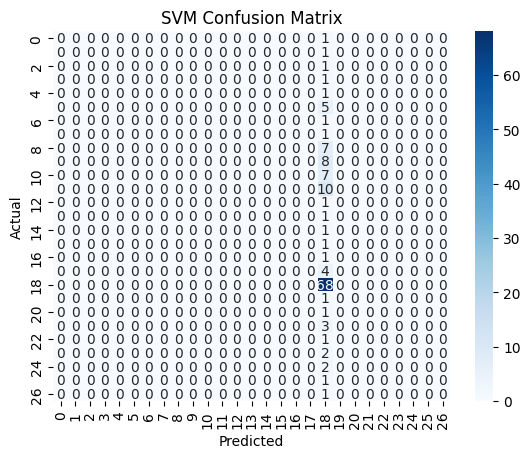

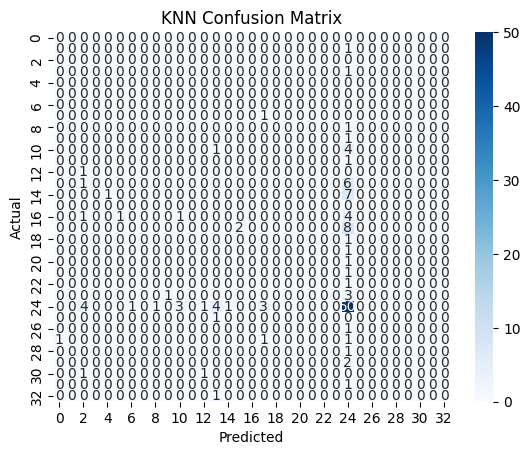

In [13]:
# Plotting the confusion matrices for both models
def plot_confusion_matrix(y_test, y_pred, title):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()

plot_confusion_matrix(y_test, y_pred_svm, 'SVM Confusion Matrix')
plot_confusion_matrix(y_test, y_pred_knn, 'KNN Confusion Matrix')

In [14]:
# Performing cross-validation and hyperparameter tuning for both models
# Defining the parameter grids for both models
svm_params = {'kernel': ['linear', 'poly', 'rbf', 'sigmoid'], 'C': [0.1, 1, 10, 100], 'gamma': [0.01, 0.1, 1, 10]}
knn_params = {'n_neighbors': [3, 5, 7, 9, 11], 'weights': ['uniform', 'distance'], 'metric': ['euclidean', 'manhattan', 'minkowski']}

# Using GridSearchCV to find the best parameters for both models
svm_grid = GridSearchCV(svm, svm_params, cv=5, scoring='accuracy')
svm_grid.fit(X_train, y_train)
knn_grid = GridSearchCV(knn, knn_params, cv=5, scoring='accuracy')
knn_grid.fit(X_train, y_train)

# Printing the best parameters and scores for both models
print("SVM best parameters:", svm_grid.best_params_)
print("SVM best score:", svm_grid.best_score_)
print("KNN best parameters:", knn_grid.best_params_)
print("KNN best score:", knn_grid.best_score_)

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:700: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:700: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


SVM best parameters: {'C': 0.1, 'gamma': 0.01, 'kernel': 'linear'}
SVM best score: 0.4744833782569632
KNN best parameters: {'metric': 'euclidean', 'n_neighbors': 11, 'weights': 'distance'}
KNN best score: 0.46312668463611867


SVM best accuracy: 0.5112781954887218
KNN best accuracy: 0.5112781954887218


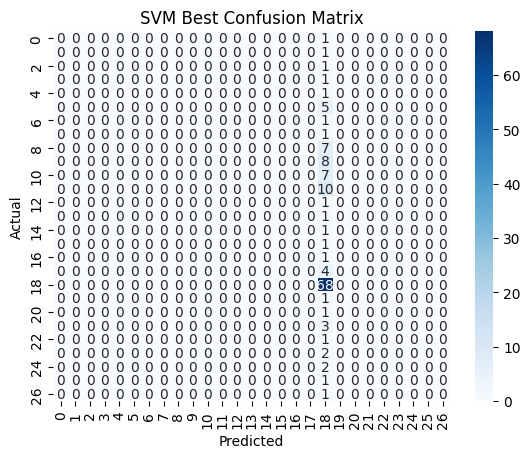

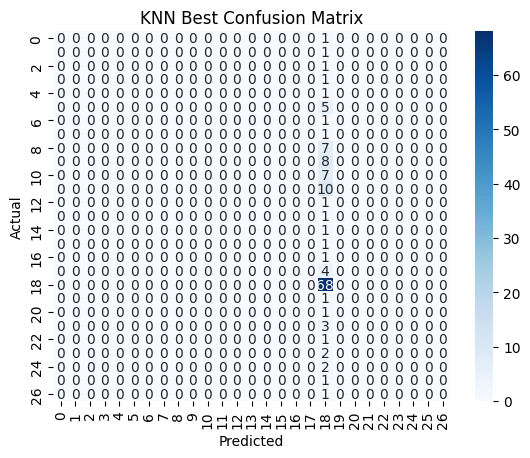

In [15]:
# Using the best parameters to retrain and retest both models
svm_best = SVC(**svm_grid.best_params_)
svm_best.fit(X_train, y_train)
y_pred_svm_best = svm_best.predict(X_test)
print("SVM best accuracy:", accuracy_score(y_test, y_pred_svm_best))

knn_best = KNeighborsClassifier(**knn_grid.best_params_)
knn_best.fit(X_train, y_train)
y_pred_knn_best = knn_best.predict(X_test)
print("KNN best accuracy:", accuracy_score(y_test, y_pred_knn_best))

# Plotting the confusion matrices for the best models
plot_confusion_matrix(y_test, y_pred_svm_best, 'SVM Best Confusion Matrix')
plot_confusion_matrix(y_test, y_pred_knn_best, 'KNN Best Confusion Matrix')
